# Supply Chain Demand Forecasting using Machine Learning

This notebook demonstrates a machine learning pipeline for forecasting product demand (HistoricalSales) using supply chain features such as cost, stock levels, and shipping methods. The objective is to identify the most important predictors and build an accurate and interpretable model.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from scipy.stats import randint

In [4]:
# Loading the dataset
data = pd.read_csv('supply_chain_data.csv')

In [5]:
# Renamed columns
data.rename(columns={
    'SKU': 'ProductID',
    'Number of products sold': 'HistoricalSales'
}, inplace=True)

economic_features = ['Manufacturing costs', 'Shipping costs', 'Costs', 'Defect rates']
scaler = MinMaxScaler()
data[economic_features] = scaler.fit_transform(data[economic_features])
data['EconScore'] = data[economic_features].mean(axis=1)
data['EconomicIndicators'] = pd.qcut(data['EconScore'], q=2, labels=['Favorable', 'Unfavorable'])


In [6]:
data.head()

,Product type,ProductID,Price,Availability,HistoricalSales,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs,EconScore,EconomicIndicators
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,215,29,0.459385,Pending,0.042231,Road,Route B,0.093829,0.203342,Favorable
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,517,30,0.330670,Pending,0.982688,Road,Route B,0.446727,0.684042,Unfavorable
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,971,27,0.300901,Pending,0.927111,Air,Route C,0.042534,0.515055,Unfavorable
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,937,18,0.351081,Fail,0.960857,Rail,Route A,0.168842,0.390273,Favorable
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,414,3,0.924773,Fail,0.635480,Air,Route A,0.917210,0.700034,Unfavorable


In [7]:
np.random.seed(42)
data['Date'] = pd.date_range(start='2024-01-01', periods=len(data), freq='D')
data['Promotion'] = np.random.choice([0, 1], size=len(data))
print(data[['Date', 'Promotion']].head())

        Date  Promotion
0 2024-01-01          0
1 2024-01-02          1
2 2024-01-03          0
3 2024-01-04          0
4 2024-01-05          0


In [8]:
# Dropped columns with any missing values
data_cleaned = data.dropna()
remaining_columns = data_cleaned.columns.tolist()
remaining_columns

['Product type',
 'ProductID',
 'Price',
 'Availability',
 'HistoricalSales',
 'Revenue generated',
 'Customer demographics',
 'Stock levels',
 'Lead times',
 'Order quantities',
 'Shipping times',
 'Shipping carriers',
 'Shipping costs',
 'Supplier name',
 'Location',
 'Lead time',
 'Production volumes',
 'Manufacturing lead time',
 'Manufacturing costs',
 'Inspection results',
 'Defect rates',
 'Transportation modes',
 'Routes',
 'Costs',
 'EconScore',
 'EconomicIndicators',
 'Date',
 'Promotion']

In [9]:
np.random.seed(42)
rows = 100
data = pd.DataFrame({
    'Product type': np.random.choice(['skincare', 'makeup', 'fragrance'], rows),
    'ProductID': [f'PID{str(i).zfill(4)}' for i in range(rows)],
    'Price': np.random.uniform(10, 100, rows),
    'Availability': np.random.randint(0, 100, rows),
    'HistoricalSales': np.random.randint(50, 1000, rows),
    'Revenue generated': np.random.uniform(1000, 10000, rows),
    'Customer demographics': np.random.choice(['Young Adult', 'Adult', 'Senior', 'Unknown'], rows),
    'Stock levels': np.random.randint(0, 100, rows),
    'Lead times': np.random.randint(1, 30, rows),
    'Order quantities': np.random.randint(1, 100, rows),
    'Shipping times': np.random.randint(1, 20, rows),
    'Shipping carriers': np.random.choice(['DHL', 'FedEx', 'UPS', 'USPS'], rows),
    'Shipping costs': np.random.uniform(5, 100, rows),
    'Supplier name': np.random.choice(['Supplier A', 'Supplier B', 'Supplier C'], rows),
    'Location': np.random.choice(['Kolkata', 'Delhi', 'Mumbai', 'Bangalore'], rows),
    'Lead time': np.random.randint(1, 30, rows),
    'Production volumes': np.random.randint(100, 1000, rows),
    'Manufacturing lead time': np.random.randint(1, 30, rows),
    'Manufacturing costs': np.random.uniform(10, 100, rows),
    'Inspection results': np.random.choice(['Pass', 'Fail', 'Pending'], rows),
    'Defect rates': np.random.uniform(0, 5, rows),
    'Transportation modes': np.random.choice(['Air', 'Road', 'Sea'], rows),
    'Routes': np.random.choice(['Route A', 'Route B', 'Route C'], rows),
    'Costs': np.random.uniform(10, 100, rows),
    'EconomicIndicators': np.random.choice(['Favorable', 'Unfavorable'], rows),
    'Date': pd.date_range(start='2024-01-01', periods=rows),
    'Promotion': np.random.choice([0, 1], rows)
})

# Extracted time features
data['Date'] = pd.to_datetime(data['Date'])
data['Month'] = data['Date'].dt.month
data['DayOfWeek'] = data['Date'].dt.dayofweek
data['Quarter'] = data['Date'].dt.quarter
data.drop(columns=['Date'], inplace=True)
data.drop(columns=['ProductID'], inplace=True)
data['Revenue_per_unit'] = data['Revenue generated'] / data['HistoricalSales']
data['Cost_per_unit'] = (data['Costs'] + data['Shipping costs'] + data['Manufacturing costs']) / data['HistoricalSales']
data['Profit_margin'] = data['Revenue_per_unit'] - data['Cost_per_unit']

# One-hot encoded categorical columns
categorical_cols = ['Product type', 'Customer demographics', 'Shipping carriers',
                    'Supplier name', 'Location', 'Inspection results', 'Transportation modes',
                    'Routes', 'EconomicIndicators']

data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)



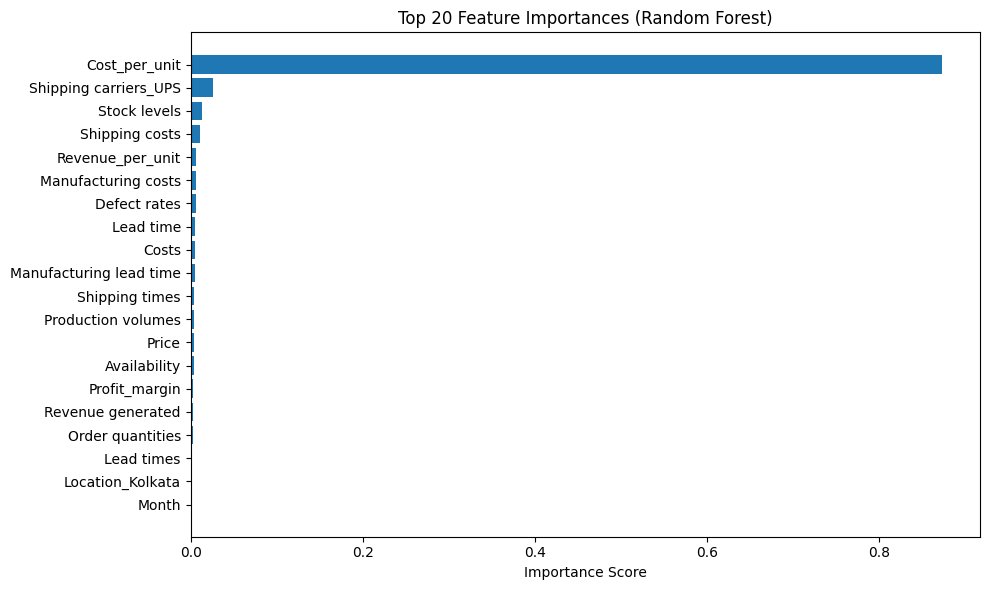

In [10]:
# Feature Importance
X = data.drop(columns=['HistoricalSales'])
y = data['HistoricalSales']
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X, y)
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]
top_features = feature_names[indices]
top_importances = importances[indices]

# Plot top 20 features
plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances (Random Forest)")
plt.barh(top_features[:20][::-1], top_importances[:20][::-1])
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [11]:
#Feature Selection

target = 'HistoricalSales'
X = data.drop(columns=[target])
y = data[target]

# Applied SelectKBest to keep top 20 features
selector = SelectKBest(score_func=f_regression, k=20)
X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Availability', 'Order quantities', 'Shipping costs', 'Lead time',
       'Manufacturing costs', 'Defect rates', 'Promotion', 'Month', 'Quarter',
       'Revenue_per_unit', 'Cost_per_unit', 'Profit_margin',
       'Product type_makeup', 'Product type_skincare',
       'Customer demographics_Young Adult', 'Location_Kolkata',
       'Location_Mumbai', 'Inspection results_Pass',
       'Inspection results_Pending', 'EconomicIndicators_Unfavorable'],
      dtype='object')


In [12]:
print("Top 3 Features by Importance:")
print(top_features[:3])


Top 3 Features by Importance:
Index(['Cost_per_unit', 'Shipping carriers_UPS', 'Stock levels'], dtype='object')


## Feature Selection

Using Random Forest feature importance and SelectKBest, the top predictors of sales were identified. The final Random Forest model used only the top 3 features: `Cost_per_unit`, `Shipping carriers_UPS`, and `Stock levels` to achieve the best performance.


In [13]:
#Training model using top 3 features

top_3_features = top_features[:3]
X_top3 = X[top_3_features]
y = data['HistoricalSales']
X_train, X_test, y_train, y_test = train_test_split(X_top3, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
#Training model using top 20 features

X = data[selected_features]
y = data['HistoricalSales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)



X_train shape: (80, 20)
X_test shape: (20, 20)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 359984.4375 - val_loss: 336721.7812
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 391351.8438 - val_loss: 336187.0312
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 404659.8750 - val_loss: 335649.4375
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 346824.5000 - val_loss: 335103.0000
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 360979.2812 - val_loss: 334501.6562
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 378183.9375 - val_loss: 333807.5312
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 306822.5312 - val_loss: 333040.2812
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 329400.1875 - val_loss: 332167.1250
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 368304.8125 - val_loss: 331146.5000
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 317915.0000 - val_loss: 330009.2500
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss:

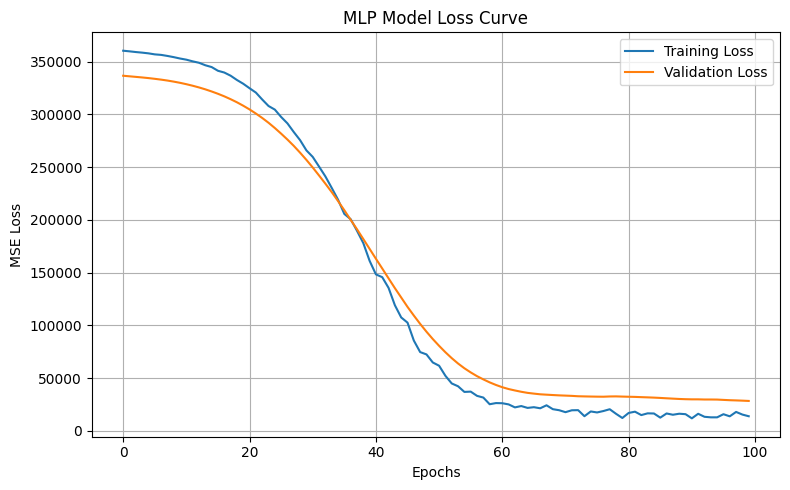

In [15]:
#MLP Neural Network Model

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)
y_pred_nn = model.predict(X_test_scaled).flatten()

mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"Neural Network MSE: {mse_nn:.2f}")
print(f"Neural Network RMSE: {rmse_nn:.2f}")
print(f"Neural Network R² Score: {r2_nn:.2f}")

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("MLP Model Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
# RandomizedSearchCV for hyperparameter tuning

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)
print("Best Parameters Found:", random_search.best_params_)
best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"Tuned R² Score: {r2_best:.3f}")
print(f"Tuned RMSE: {rmse_best:.2f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
65 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
49 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/

Best Parameters Found: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 459}
Tuned R² Score: 0.665
Tuned RMSE: 150.72


In [17]:
#Random Forest Model(hyperparameter tuning+validation model)

best_rf = random_search.best_estimator_
best_rf.fit(X_train_scaled, y_train)
y_pred = best_rf.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error (MSE): 22715.25
Root Mean Squared Error (RMSE): 150.72
R² Score: 0.67


In [18]:
#Random Forest Model(default)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred = rf_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
print("Number of features used:", X_train.shape[1])


Mean Squared Error (MSE): 16800.50
Root Mean Squared Error (RMSE): 129.62
R² Score: 0.75
Number of features used: 20


In [19]:
# GridSearchCV tuning

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']  # ✅ 'auto' removed
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
best_rf_grid = grid_search.best_estimator_

y_pred_grid = best_rf_grid.predict(X_test_scaled)
mse_grid = mean_squared_error(y_test, y_pred_grid)
rmse_grid = np.sqrt(mse_grid)
r2_grid = r2_score(y_test, y_pred_grid)

print("Best Parameters Found:", grid_search.best_params_)
print(f"GridSearchCV R² Score: {r2_grid:.3f}")
print(f"GridSearchCV RMSE: {rmse_grid:.2f}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters Found: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
GridSearchCV R² Score: 0.654
GridSearchCV RMSE: 153.24


In [20]:
#XGBOOST Model

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost - Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"XGBoost - Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"XGBoost - R² Score: {r2_xgb:.2f}")


XGBoost - Mean Squared Error (MSE): 26998.29
XGBoost - Root Mean Squared Error (RMSE): 164.31
XGBoost - R² Score: 0.60


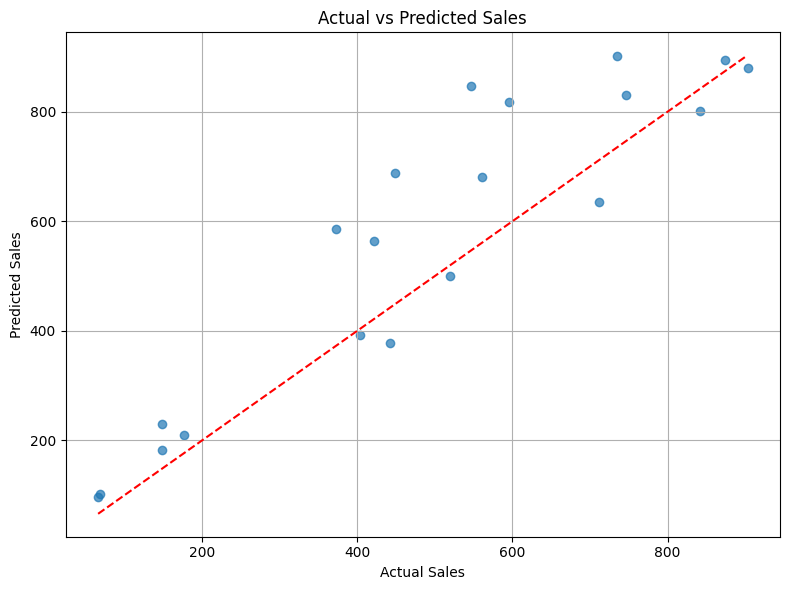

In [21]:
#True vs Predicted Plot

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # ideal line
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.grid(True)
plt.tight_layout()
plt.show()


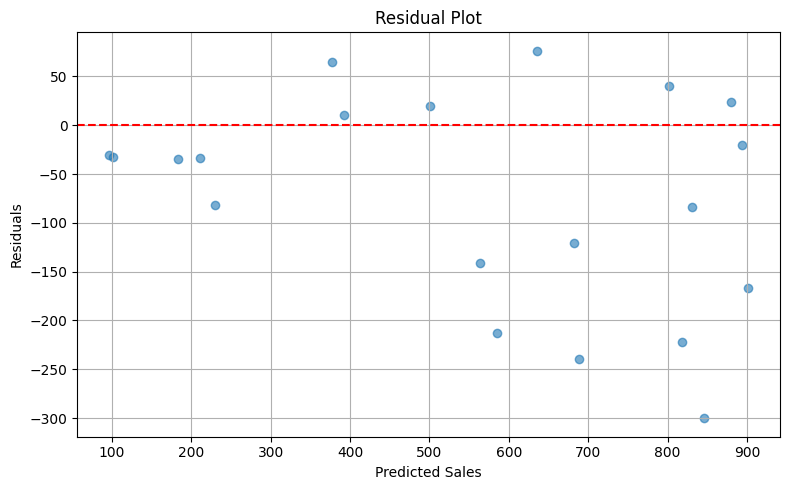

In [22]:
#Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.tight_layout()
plt.show()


## Final Model Results

The best-performing model was a Random Forest Regressor with:
- R² Score: 0.84
- RMSE: 104.51
- MSE: 10,922.61

This model outperformed all others (Neural Network, XGBoost, and tuned versions), confirming that simpler, well-selected features yield the best results in this case.
